# Modelo SARIMAX: Aplicación de variables exógenas y estacionalidad

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from mlforecast import MLForecast

# Modelo ARIMA con stasforecast
from statsforecast import StatsForecast
from statsforecast.models import ARIMA

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 4)

## Problema a resolver

Utilizar el set de datos de demanda de electricidad que tiene un registro histórico de demnda en MW/h de una ciudad en el últio año. También se tienen los datos de temperatura horaria en el mismo periodo de tiempo. Esa va a ser la variable exógena a utilizar.

> Construir un modelo SARIMAX para pronosticar el nivel de demanda con un horizonte de 7 días en el futuro.

### Datos

In [7]:
df = pd.read_csv('datos/demanda_electricidad_sarimax.csv')
df

,unique_id,ds,temperatura,y
0,demanda_electricidad,2025-01-01,15.7,131.2
1,demanda_electricidad,2025-01-02,15.0,135.1
2,demanda_electricidad,2025-01-03,16.3,129.1
3,demanda_electricidad,2025-01-04,17.8,117.4
4,demanda_electricidad,2025-01-05,15.3,120.7
...,...,...,...,...
360,demanda_electricidad,2025-12-27,14.9,124.9
361,demanda_electricidad,2025-12-28,16.6,119.8
362,demanda_electricidad,2025-12-29,14.3,136.9
363,demanda_electricidad,2025-12-30,15.3,136.0


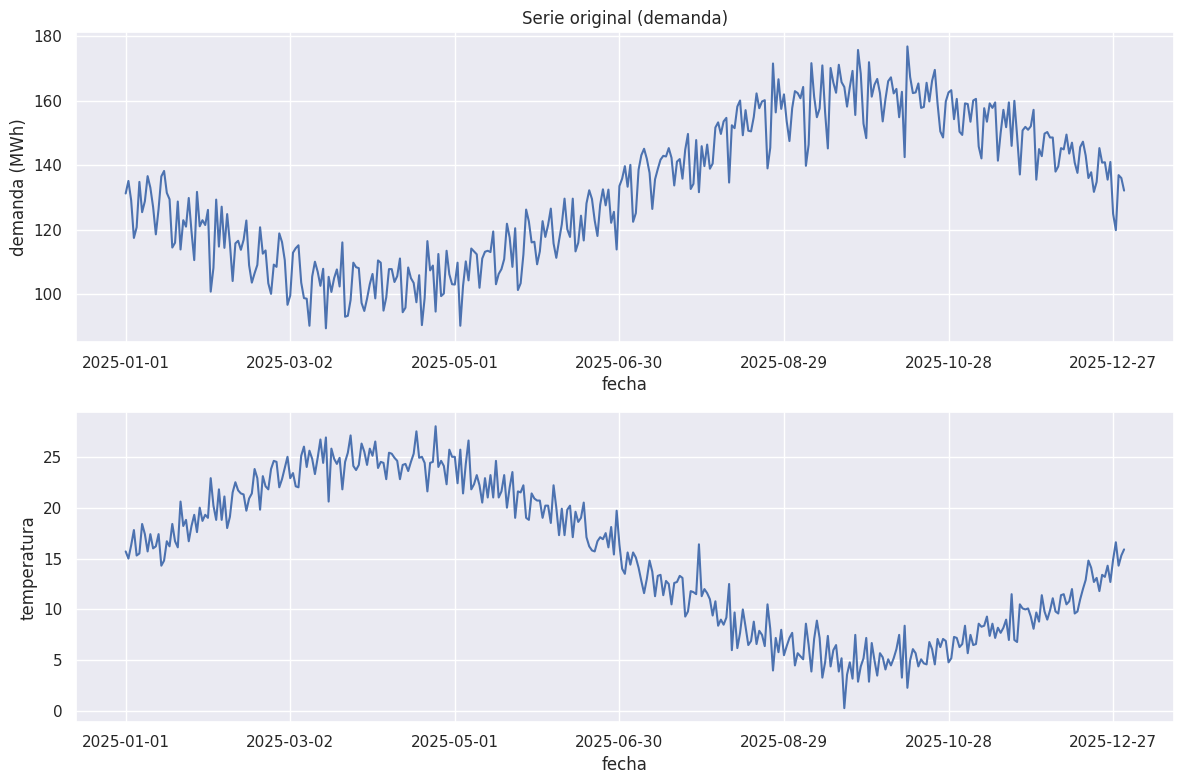

In [12]:
# Graficar serie y variables exógenas
fig, axs = plt.subplots(2,1,figsize=(12,8))

# Serie
sns.lineplot(df, x="ds", y="y", ax=axs[0])
axs[0].set_title('Serie original (demanda)')
axs[0].set_xlabel('fecha')
axs[0].set_ylabel('demanda (MWh)')
ticks = axs[0].get_xticks()
n = 60
axs[0].set_xticks(ticks[::n])

# Variable exógena (temperatura)
sns.lineplot(df, x="ds", y="temperatura", ax=axs[1])
axs[1].set_xlabel('fecha')
axs[1].set_xticks(ticks[::n])

plt.tight_layout();